<a href="https://colab.research.google.com/github/adljna/ProjectA-Group3-KematianAliKhamenei/blob/main/Article%20Link%20Scrapping/CNN/1-CNN-ScrapingLink.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Indonesia — Content Scraping & Preprocessing
**Input :** `scraping_cnn_100pages_clean.csv` (kolom: Judul, Link, Kategori, Tanggal_Upload)
**Output :** `cnn_analyzed_articles.csv` (+ kolom content, preprocessing, sentimen)

Alur:
1. Instalasi Library
2. Impor Library
3. Upload CSV & Scraping Konten tiap Link → kolom `content`
4. Preprocessing (clean → tokenize → stopword → stem → deteksi bahasa)
5. Analisis Sentimen (translate → TextBlob)
6. Visualisasi Word Cloud
7. Ekspor CSV

## **(1) Instalasi Library**

In [1]:
# Library scraping & data
!pip install -q beautifulsoup4 requests pandas

# Polyglot (deteksi bahasa) — perlu urutan ini agar tidak konflik
!pip uninstall -q -y icu polyglot pyicu 2>/dev/null
!pip install -q polyglot pycld2 pyicu morfessor

# NLP
!pip install -q deep-translator Sastrawi stanza nltk wordcloud

print('✅ Semua library berhasil diinstall')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.3/126.3 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.2/268.2 kB 13.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 26.4 MB/s eta 0:00:00
✅ Semua library berhasil diinstall


## **(2) Impor Library**

In [2]:
# Standard
import io, string, re, time
from collections import defaultdict, Counter

# Data
import pandas as pd
import numpy as np

# Scraping
import requests
from bs4 import BeautifulSoup

# NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

# Sastrawi (stemming)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Sentimen
from textblob import TextBlob
from deep_translator import GoogleTranslator

# Visualisasi
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# NLTK downloads
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print('✅ Semua library berhasil diimpor')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ Semua library berhasil diimpor


## **(3) Upload CSV & Scraping Konten tiap Link**

In [8]:
from google.colab import files
import os

print('📂 Upload file CSV hasil scraping link (scraping_cnn_100pages_clean.csv)')

# Clear previously uploaded files to avoid confusion if an incorrect file was uploaded.
# This part ensures a fresh upload attempt.
# for f in files.upload(): # This loop usually gets an uploaded file. If the cell was run, 'uploaded' would be populated.
#   os.remove(f)

# The 'uploaded' variable is a dictionary of {filename: content}.
# If it already exists from a previous run, clear it.
if 'uploaded' in locals() or 'uploaded' in globals():
    uploaded = {}

uploaded = files.upload()

if not uploaded:
    print('Tidak ada file yang diunggah. Pastikan Anda memilih file CSV.')
    # If no file is uploaded, we might want to prevent further execution or ask to re-upload.
    # For now, let's just print a message and proceed, assuming the user might re-run.
else:
    filename = list(uploaded.keys())[0]
    # Check if the uploaded file has a .csv extension
    if not filename.lower().endswith('.csv'):
        print(f'⚠️  File yang diunggah bukan file CSV: {filename}. Mohon unggah file CSV yang benar.')
        # Clear the uploaded content to ensure the next cell doesn't try to process it.
        uploaded = {}
        # You might want to raise an error or exit here if you want to strictly enforce CSV upload.
        # raise ValueError('Uploaded file must be a CSV.')
    else:
        print(f'✅ File terupload: {filename}')


📂 Upload file CSV hasil scraping link (scraping_cnn_100pages_clean.csv)


Saving scraping_cnn_100pages_clean (1).csv to scraping_cnn_100pages_clean (1).csv
✅ File terupload: scraping_cnn_100pages_clean (1).csv


In [35]:
# Baca CSV
links_df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'Jumlah baris: {len(links_df)}')
print(f'Kolom       : {links_df.columns.tolist()}')
links_df.head(3)

Jumlah baris: 99
Kolom       : ['Judul', 'Link', 'Kategori', 'Tanggal_Upload']


,Judul,Link,Kategori,Tanggal_Upload
0,Isi Dokumen Fatwa Ali Khamenei Mengharamkan Bo...,https://www.cnnindonesia.com/internasional/202...,Internasional,3 hari yang lalu
1,"Tanpa Ali Khamenei, Israel Justru Ketar-ketir ...",https://www.cnnindonesia.com/internasional/202...,Internasional,4 hari yang lalu
2,Trump Konfirmasi Kematian Pemimpin Tertinggi I...,https://www.cnnindonesia.com/internasional/202...,Internasional,2 bulan yang lalu


In [36]:
# ── Fungsi scraping konten satu artikel CNN Indonesia ────────────────────────
HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    )
}

def scrape_content(url):
    """
    Ambil SEMUA teks yang terlihat di halaman artikel CNN Indonesia.
    Strategi:
      1. Coba selector utama CNN Indonesia (detail_text / article body)
      2. Fallback: ambil semua <p> di seluruh halaman
      3. Last resort: get_text() seluruh <body> bersih dari tag
    """
    try:
        response = requests.get(url, headers=HEADERS, timeout=15)
        if response.status_code != 200:
            return None

        soup = BeautifulSoup(response.content, 'html.parser')

        # Hapus elemen non-konten (nav, header, footer, script, style, ads)
        for tag in soup(['script', 'style', 'noscript', 'nav', 'header',
                         'footer', 'aside', 'iframe', 'figure']):
            tag.decompose()

        # ── Prioritas 1: div.detail_text (body artikel CNN Indonesia) ──────
        content_div = (
            soup.find('div', class_='detail_text') or
            soup.find('div', class_=lambda c: c and 'detail_text' in c) or
            soup.find('div', class_=lambda c: c and 'article-body' in c) or
            soup.find('article')
        )

        if content_div:
            # Ambil semua teks di dalam container tersebut
            paragraphs = content_div.find_all(['p', 'h1', 'h2', 'h3', 'li'])
            text = '\n'.join(
                p.get_text(separator=' ', strip=True)
                for p in paragraphs
                if p.get_text(strip=True)
            )
            if text:
                return text

        # ── Prioritas 2: semua <p> di halaman ──────────────────────────────
        paragraphs = soup.find_all('p')
        text = '\n'.join(
            p.get_text(separator=' ', strip=True)
            for p in paragraphs
            if p.get_text(strip=True)
        )
        if text:
            return text

        # ── Prioritas 3 (last resort): seluruh body ─────────────────────────
        body = soup.find('body')
        if body:
            return re.sub(r'\n{3,}', '\n\n', body.get_text(separator='\n', strip=True))

        return None

    except Exception as e:
        return None


# ── Loop scraping semua link ──────────────────────────────────────────────────
if 'Link' not in links_df.columns:
    raise ValueError("Kolom 'Link' tidak ditemukan di CSV!")

urls = links_df['Link'].tolist()
contents = []

for i, url in enumerate(urls, 1):
    print(f'[{i:>3}/{len(urls)}] Scraping... {url[:80]}')
    content = scrape_content(url)
    contents.append(content)
    time.sleep(1)   # jeda sopan agar tidak diblok server

# Tambahkan kolom 'content' ke dataframe asli
df_article = links_df.copy()
df_article['content'] = contents

# Simpan versi mentah dengan kolom content
df_article.to_csv('cnn_with_content.csv', index=False, encoding='utf-8-sig')

print(f'\n✅ Selesai! {df_article["content"].notna().sum()}/{len(df_article)} artikel berhasil discrape.')
print(f'💾 Disimpan ke cnn_with_content.csv')
df_article.head(3)

[  1/99] Scraping... https://www.cnnindonesia.com/internasional/20260428200911-120-1353182/isi-dokume
[  2/99] Scraping... https://www.cnnindonesia.com/internasional/20260428135252-120-1353013/tanpa-ali-
[  3/99] Scraping... https://www.cnnindonesia.com/internasional/20260301044904-134-1332937/trump-konf
[  4/99] Scraping... https://www.cnnindonesia.com/internasional/20260501153618-134-1354171/trump-bing
[  5/99] Scraping... https://www.cnnindonesia.com/internasional/20260420111520-120-1349957/kenapa-ira
[  6/99] Scraping... https://www.cnnindonesia.com/internasional/20260304191525-120-1334389/mojtaba-kh
[  7/99] Scraping... https://www.cnnindonesia.com/internasional/20260301090739-120-1332969/waktu-terb
[  8/99] Scraping... https://www.cnnindonesia.com/internasional/20260309044622-120-1335708/tok-anak-a
[  9/99] Scraping... https://www.cnnindonesia.com/internasional/20260301174003-120-1333089/hamas-ucap
[ 10/99] Scraping... https://www.cnnindonesia.com/internasional/20260305065848-120

,Judul,Link,Kategori,Tanggal_Upload,content
0,Isi Dokumen Fatwa Ali Khamenei Mengharamkan Bo...,https://www.cnnindonesia.com/internasional/202...,Internasional,3 hari yang lalu,Isi Dokumen Fatwa Ali Khamenei Mengharamkan Bo...
1,"Tanpa Ali Khamenei, Israel Justru Ketar-ketir ...",https://www.cnnindonesia.com/internasional/202...,Internasional,4 hari yang lalu,"Tanpa Ali Khamenei, Israel Justru Ketar-ketir ..."
2,Trump Konfirmasi Kematian Pemimpin Tertinggi I...,https://www.cnnindonesia.com/internasional/202...,Internasional,2 bulan yang lalu,Trump Konfirmasi Kematian Pemimpin Tertinggi I...


## **(4) Data Preprocessing**

Langkah: clean → tokenize → hapus stopwords → stemming → deteksi bahasa

In [37]:
# ── Inisialisasi stemmer Sastrawi ─────────────────────────────────────────────
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

# ── Stopwords Indonesia dari NLTK ────────────────────────────────────────────
list_stopwords = nltk.corpus.stopwords.words('indonesian')

# Tambahkan stop word kustom
custom_stopwords_phrase = "advertisement scroll to continue with content"
# Split the phrase into words and add them to the list of stopwords
list_stopwords.extend(custom_stopwords_phrase.lower().split())
# Remove duplicates if any (though unlikely for this specific phrase)
list_stopwords = list(set(list_stopwords))

# ── Fungsi preprocessing ─────────────────────────────────────────────────────
def clean_text(text):
    """Lowercase, hapus URL/mention/angka/tanda baca/spasi berlebih."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)          # hapus URL
    text = re.sub(r'@\w+', '', text)                            # hapus mention
    text = re.sub(r'\d+', '', text)                             # hapus angka
    text = text.translate(str.maketrans('', '', string.punctuation))  # hapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip()                   # normalisasi spasi
    return text

def tokenize_text(text):
    """Memecah teks menjadi token kata."""
    if not isinstance(text, str):
        return []
    return word_tokenize(text)

def remove_stopwords(tokens, stopwords_list):
    """Hapus kata umum (stopwords)."""
    return [w for w in tokens if w not in stopwords_list and w.strip() != '']

def stem_text(tokens):
    """Kembalikan kata ke bentuk dasar dengan Sastrawi."""
    return [stemmer.stem(w) for w in tokens]

print('✅ Fungsi preprocessing siap')


✅ Fungsi preprocessing siap


In [38]:
# ── Terapkan semua langkah preprocessing ─────────────────────────────────────
print('⏳ Cleaning teks...')
df_article['text_cleaned'] = df_article['content'].fillna('').apply(clean_text)

print('⏳ Tokenisasi...')
df_article['tokens'] = df_article['text_cleaned'].apply(tokenize_text)

print('⏳ Hapus stopwords...')
df_article['tokens_no_stop'] = df_article['tokens'].apply(
    lambda x: remove_stopwords(x, list_stopwords)
)

print('⏳ Stemming (proses terlama)...')
df_article['tokens_stemmed'] = df_article['tokens_no_stop'].apply(stem_text)

print('⏳ Gabungkan token hasil stem...')
df_article['text_final'] = df_article['tokens_stemmed'].apply(lambda x: ' '.join(x))

print('\n✅ Preprocessing selesai!')
print(df_article[['content', 'text_cleaned', 'tokens', 'tokens_no_stop', 'tokens_stemmed', 'text_final']].head(3))

⏳ Cleaning teks...
⏳ Tokenisasi...
⏳ Hapus stopwords...
⏳ Stemming (proses terlama)...
⏳ Gabungkan token hasil stem...

✅ Preprocessing selesai!
                                             content  \
0  Isi Dokumen Fatwa Ali Khamenei Mengharamkan Bo...   
1  Tanpa Ali Khamenei, Israel Justru Ketar-ketir ...   
2  Trump Konfirmasi Kematian Pemimpin Tertinggi I...   

                                        text_cleaned  \
0  isi dokumen fatwa ali khamenei mengharamkan bo...   
1  tanpa ali khamenei israel justru ketarketir fa...   
2  trump konfirmasi kematian pemimpin tertinggi i...   

                                              tokens  \
0  [isi, dokumen, fatwa, ali, khamenei, mengharam...   
1  [tanpa, ali, khamenei, israel, justru, ketarke...   
2  [trump, konfirmasi, kematian, pemimpin, tertin...   

                                      tokens_no_stop  \
0  [isi, dokumen, fatwa, ali, khamenei, mengharam...   
1  [ali, khamenei, israel, ketarketir, fatwa, bom...   
2  [trump, k

In [39]:
# ── Deteksi Bahasa dengan Polyglot ───────────────────────────────────────────
from polyglot.text import Text

print('Deteksi bahasa pada 5 artikel pertama:')
for index, row in df_article.head(5).iterrows():
    try:
        text = Text(row['content'] if pd.notna(row['content']) else '')
        if text.language.code:
            print(f'  Row {index}: Code={text.language.code}, Name={text.language.name}')
        else:
            print(f'  Row {index}: Deteksi bahasa gagal')
    except Exception as e:
        print(f'  Row {index}: Error — {e}')

Deteksi bahasa pada 5 artikel pertama:
  Row 0: Code=id, Name=Indonesian
  Row 1: Code=id, Name=Indonesian
  Row 2: Code=id, Name=Indonesian
  Row 3: Code=id, Name=Indonesian
  Row 4: Code=id, Name=Indonesian


## **(5) Analisis Sentimen**

Terjemahkan teks Indonesia → Inggris menggunakan GoogleTranslator, lalu analisis polaritas dengan TextBlob.

In [40]:
def analyze_long_text_sentiment(text):
    """Analisis sentimen teks panjang dengan chunking."""
    if not isinstance(text, str) or not text.strip():
        return pd.Series([None, None])

    try:
        if len(text) < 4500:
            translated = GoogleTranslator(source='id', target='en').translate(text)
            blob = TextBlob(translated)
            return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])
        else:
            max_chunk = 4500
            chunks = [text[i:i+max_chunk] for i in range(0, len(text), max_chunk)]
            translated_parts = []
            for i, chunk in enumerate(chunks):
                if i > 0:
                    time.sleep(0.5)
                translated_parts.append(
                    GoogleTranslator(source='id', target='en').translate(chunk)
                )
            full_translated = ' '.join(translated_parts)
            blob = TextBlob(full_translated)
            return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])
    except Exception as e:
        print(f'  ⚠️  Error sentimen: {e}')
        return pd.Series([None, None])


def get_sentiment_label(polarity):
    if polarity is None:
        return 'Undefined'
    elif polarity > 0.05:
        return 'Positive'
    elif polarity < -0.05:
        return 'Negative'
    else:
        return 'Netral'

print('✅ Fungsi sentimen siap')

✅ Fungsi sentimen siap


In [41]:
print('⏳ Analisis sentimen (proses paling lama — tergantung kecepatan terjemahan)...')
df_article[['polarity', 'subjectivity']] = df_article['text_final'].apply(analyze_long_text_sentiment)

df_article['polarity'].fillna(0, inplace=True)
df_article['sentiment_label'] = df_article['polarity'].apply(get_sentiment_label)

print('\n✅ Analisis sentimen selesai!')
print(df_article[['Judul', 'text_final', 'polarity', 'subjectivity', 'sentiment_label']].head(5).to_string())
print('\nDistribusi sentimen:')
print(df_article['sentiment_label'].value_counts())

⏳ Analisis sentimen (proses paling lama — tergantung kecepatan terjemahan)...

✅ Analisis sentimen selesai!
                                                                   Judul                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

/tmp/ipykernel_1495/1192213517.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_article['polarity'].fillna(0, inplace=True)


## **(6) Visualisasi Word Cloud**

Artikel Positif : 51
Artikel Negatif : 10


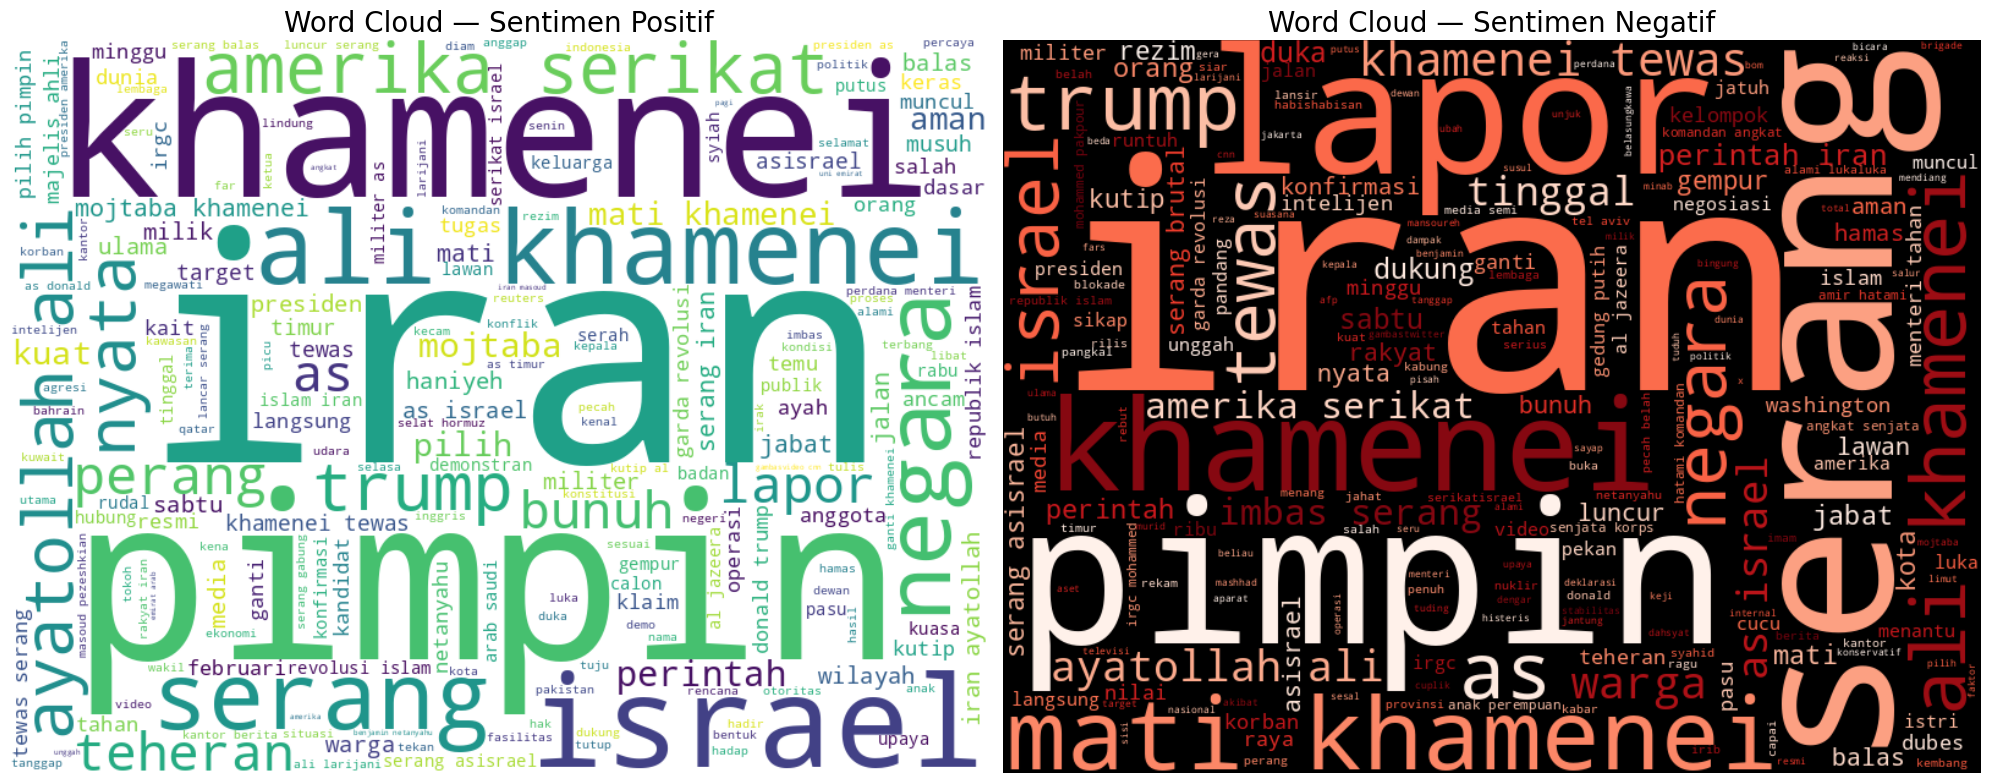

✅ Word cloud disimpan ke wordcloud_sentimen.png


In [42]:
positive_df = df_article[df_article['sentiment_label'] == 'Positive']
negative_df = df_article[df_article['sentiment_label'] == 'Negative']

print(f'Artikel Positif : {len(positive_df)}')
print(f'Artikel Negatif : {len(negative_df)}')

positive_text = ' '.join(positive_df['text_final'].dropna())
negative_text = ' '.join(negative_df['text_final'].dropna())

plt.figure(figsize=(20, 10))

if positive_text:
    plt.subplot(1, 2, 1)
    wc_pos = WordCloud(
        stopwords=set(list_stopwords),
        width=800, height=600,
        background_color='white',
        colormap='viridis'
    ).generate(positive_text)
    plt.imshow(wc_pos, interpolation='bilinear')
    plt.title('Word Cloud — Sentimen Positif', fontsize=20)
    plt.axis('off')
else:
    print('Tidak ada teks positif untuk Word Cloud.')

if negative_text:
    plt.subplot(1, 2, 2)
    wc_neg = WordCloud(
        stopwords=set(list_stopwords),
        width=800, height=600,
        background_color='black',
        colormap='Reds'
    ).generate(negative_text)
    plt.imshow(wc_neg, interpolation='bilinear')
    plt.title('Word Cloud — Sentimen Negatif', fontsize=20)
    plt.axis('off')
else:
    print('Tidak ada teks negatif untuk Word Cloud.')

plt.tight_layout()
plt.savefig('wordcloud_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Word cloud disimpan ke wordcloud_sentimen.png')

## **(7) Ekspor Hasil**

In [43]:
# Rename columns
df_article = df_article.rename(columns={'Judul': 'title', 'Link': 'url'})

# Drop columns
df_article = df_article.drop(columns=['Kategori', 'Tanggal_Upload'], errors='ignore')

# Kolom urutan output
cols_order = [
    'url', 'title', 'content',
    'text_cleaned', 'tokens', 'tokens_no_stop', 'tokens_stemmed', 'text_final',
    'polarity', 'subjectivity', 'sentiment_label'
]
# Hanya ambil kolom yang ada
cols_order = [c for c in cols_order if c in df_article.columns]

df_final = df_article[cols_order]
df_final.to_csv('cnn_analyzed_articles.csv', index=False, encoding='utf-8-sig')

print(f'✅ File disimpan: cnn_analyzed_articles.csv')
print(f'   Jumlah baris : {len(df_final)}')
print(f'   Kolom        : {df_final.columns.tolist()}')
print(df_final.head(3).to_string())


✅ File disimpan: cnn_analyzed_articles.csv
   Jumlah baris : 99
   Kolom        : ['url', 'title', 'content', 'text_cleaned', 'tokens', 'tokens_no_stop', 'tokens_stemmed', 'text_final', 'polarity', 'subjectivity', 'sentiment_label']
                                                                                                                                        url                                                                title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [44]:
from google.colab import files
files.download('cnn_analyzed_articles.csv')
files.download('wordcloud_sentimen.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>